## This notebook plots the representative DVs for all datasets

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from src.feature_extraction import coarsen_density
import yaml

def parse_dataset2_file_name(index):
    combo_num, remainder = divmod(index, 1210)
    param1_num, remainder = divmod(remainder, 11*10)
    param2_num, itr = divmod(remainder, 10)
    
    with open("../src/parameters.yaml") as p:
        params = yaml.safe_load(p)
        dataset2_info = params["dataset2"]
        param_combinations = dataset2_info['parameter_combinations']
    
    combo = param_combinations[combo_num]
    param1, param2 = combo.split(",")
    
    param1_base = dataset2_info["parameters"][param1]
    param2_base = dataset2_info["parameters"][param2]
            
    param1_range = np.logspace(
        np.log2(param1_base / 2), np.log2(2 * param1_base), 11, base = 2
    )
    param2_range = np.logspace(
        np.log2(param2_base / 2), np.log2(2 * param2_base), 11, base = 2
    )
    file_name = f"../data/dataset2/({param1},{param2})/{param1}={param1_range[param1_num]}_{param2}={param2_range[param2_num]}_itr={itr}.npz"
    
    return file_name

def parse_dataset1_file_name(index):
    c_a_num, remainder = divmod(index, 11*10)
    eta1_num, itr = divmod(remainder, 10)
    
    with open("../src/parameters.yaml") as p:
        params = yaml.safe_load(p)
        dataset1_info = params["dataset1"]
    
    c_a_base = dataset1_info["parameters"]["c_a"]
    eta1_base = dataset1_info["parameters"]["eta1"]
            
    c_a_range = np.logspace(
        np.log2(c_a_base / 2), np.log2(2 * c_a_base), 11, base = 2
    )
    eta1_range = np.logspace(
        np.log2(eta1_base / 2), np.log2(2 * eta1_base), 11, base = 2
    )
    file_name = f"../data/dataset1/c_a={c_a_range[c_a_num]}_eta1={eta1_range[eta1_base]}_itr={itr}.npz"
    
    return file_name

def plot_cell_counts(ax,out):

    Nr = out['Nr']
    Ny = out['Ny']
    Ng = out['Ng']
    Nd = out['Nd']
    
    ax.plot(np.arange(0,241), Nr,linewidth = 5, color = 'tab:red', label = '$N_r(t)$')
    ax.plot(np.arange(0,241), Ny,linewidth = 5, color = 'yellow',  label = '$N_y(t)$')
    ax.plot(np.arange(0,241), Ng,linewidth = 5, color = 'limegreen',  label = '$N_g(t)$')
    ax.plot(np.arange(0,241), Nd,linewidth = 5, color = 'lightseagreen',  label = '$N_d(t)$')
    ax.set_xlim(0,240)
    
def plot_final_density(ax,out,cbar=False):

    v = out['v']
    h = out['L']/(out['I'] - 1)
    coarse_v = coarsen_density(v.reshape(out['I'],out['I']), I = 200, h = 1000/(199.0), bin_size = coarseness).reshape((coarse_resolution,coarse_resolution))
    im = ax.imshow(coarse_v,vmin=0,vmax = 2e-2)
    if cbar == True:
        cbar = plt.colorbar(im, ax = ax, fraction = 0.046,orientation = 'vertical',ticks = [0.00, 0.01, 0.02], label = r'Density $(\mathrm{cells}~\mathrm{\mu m}^{-2})$')
        cbar.ax.set_yticks([0.00, 0.01, 0.02],labels=[0.00, 0.01, 0.02],fontsize=25)
        cbar.ax.set_ylabel(r'Density $(\mathrm{cells}~\mathrm{\mu m}^{-2})$',fontsize=25)
    

## Dataset 1

In [2]:
num_clusters = 4
assert os.path.isfile(f"../results/dataset1/density_phenotype_inds_{num_clusters}_clusters.npy")
assert os.path.isfile(f"../results/dataset1/cell_counts_phenotype_inds_{num_clusters}_clusters.npy")

### Cell counts

../data/dataset1/c_a=0.2_eta1=4.999999999999999_itr=0.npz
../data/dataset1/c_a=0.2639015821545788_eta1=4.999999999999999_itr=0.npz
../data/dataset1/c_a=0.4_eta1=4.999999999999999_itr=4.npz
../data/dataset1/c_a=0.6062866266041593_eta1=4.999999999999999_itr=3.npz


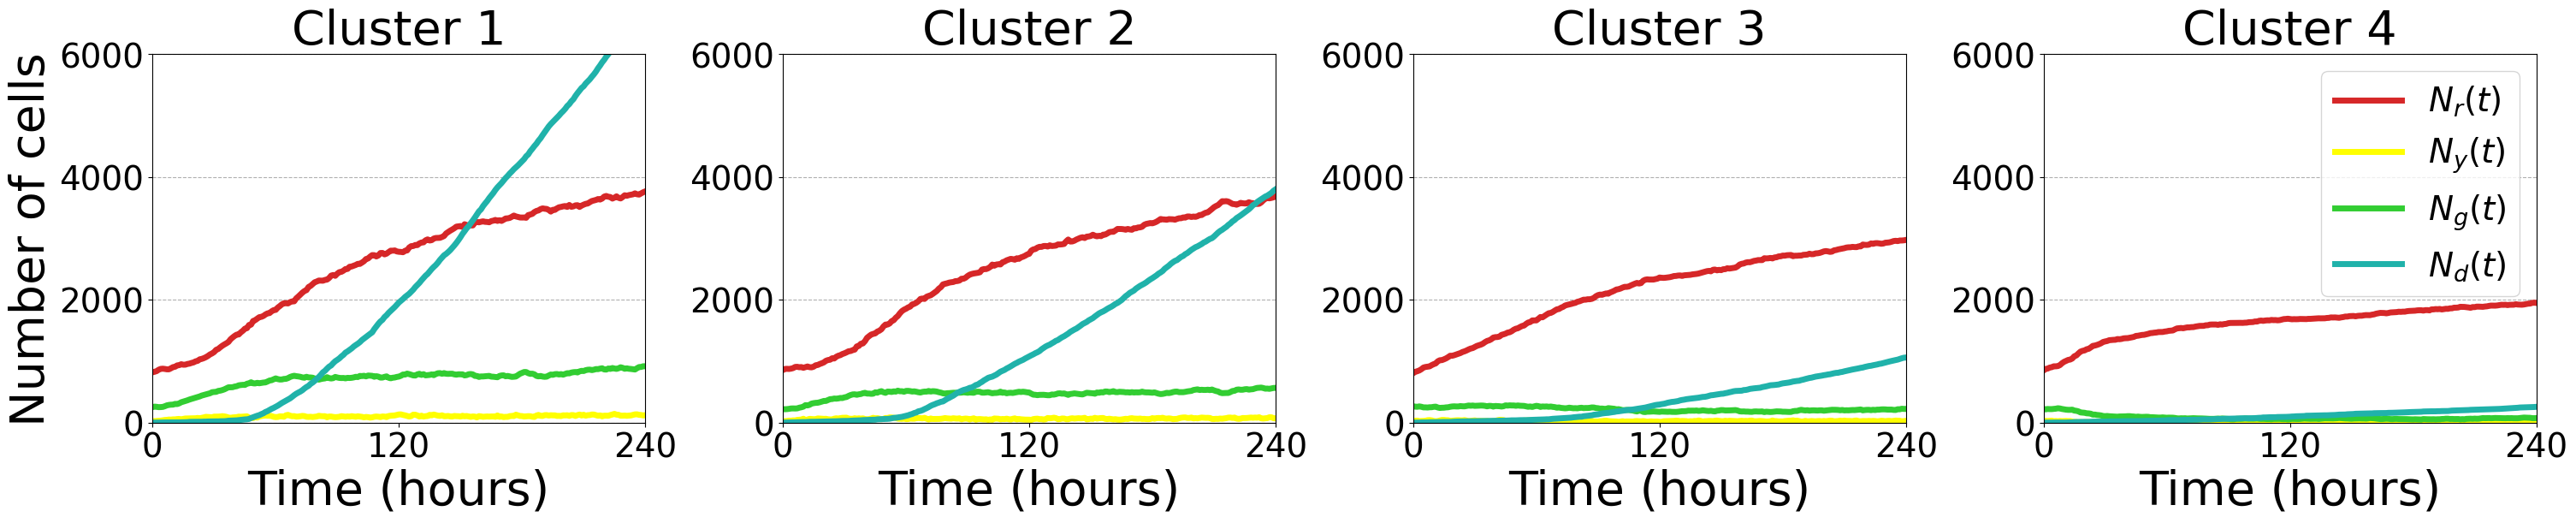

In [3]:
cell_counts_phenotype_inds = np.load(f"../results/dataset1/cell_counts_phenotype_inds_{num_clusters}_clusters.npy", allow_pickle = True)

fig, axes = plt.subplots(1,4, figsize = (30,6),layout="constrained")

for c, ind in enumerate(cell_counts_phenotype_inds):
    
    file_name = parse_dataset1_file_name(ind)
    print(file_name)
    out = np.load(file_name)
    plot_cell_counts(axes[c], out)

fontsize=40
for c in range(4):
    ax = axes[c]
    
    if c == 0:
        ax.set_ylabel('Number of cells', fontsize=fontsize)
    if c == 3:
        ax.legend(loc='best', fontsize = fontsize*.7)
        
    ax.set_xlabel('Time (hours)', fontsize=fontsize)
    ax.set_title(f'Cluster {c+1}', fontsize=fontsize)
    ax.set_ylim(0,6000)

    ax.set_xticks([0,120,240],[0,120,240],fontsize=28)
    ax.set_yticks([0,2e3,4e3,6e3],[0,2000,4000,6000],fontsize=28)
    ax.grid(axis="y",linestyle="--")

plt.savefig('../figures/dataset1/cell_count_DVs.png')    

### Density

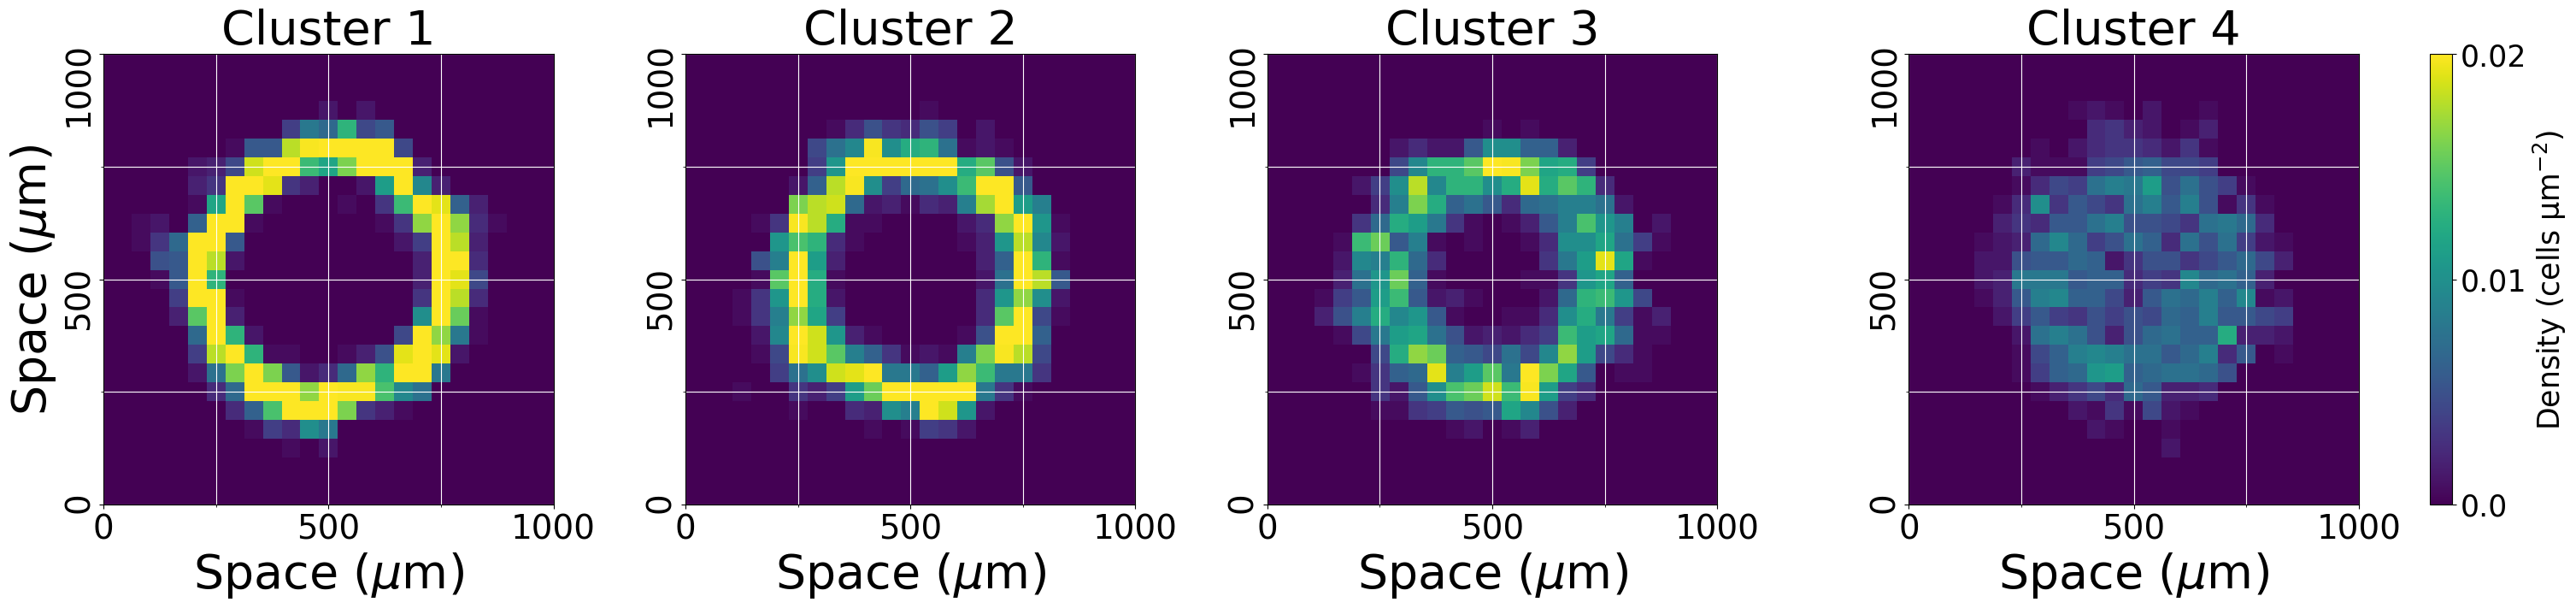

In [4]:
density_phenotype_inds = np.load("../results/dataset1/density_phenotype_inds_4_clusters.npy", allow_pickle = True)
coarseness = 8
coarse_resolution = (200//coarseness)

fig, axes = plt.subplots(1,4, figsize = (30,7),layout="constrained")

for c, ind in enumerate(density_phenotype_inds):
    
    file_name = parse_dataset1_file_name(ind)
    
    out = np.load(file_name, allow_pickle = True)
    
    cbar = c == 3
    
    plot_final_density(axes[c],out,cbar)

fontsize = 40
for c in range(4):
    
    ax = axes[c]
    
    if c == 0:
        ax.set_ylabel(r"Space ($\mu$m)",fontsize=fontsize)
    
    ax.set_xlabel(r"Space ($\mu$m)",fontsize=fontsize)
    ax.set_xticks(ticks = [0, 12, 24], labels = [0, 500, 1000],fontsize=28)
    ax.set_xticks(ticks = [6,18], labels = None,minor=True)
    ax.set_yticks(ticks = [0, 12, 24], labels = [0, 500, 1000],rotation=90,fontsize=28)
    ax.set_yticks(ticks = [6,18], labels = None,minor=True)
    ax.invert_yaxis()
    
    ax.set_xlim([0,24])
    ax.set_ylim([0,24])
    
    ax.set_title(f'Cluster {c+1}', fontsize=fontsize)
    
    ax.grid(color="white",which="both")
    
plt.savefig('../figures/dataset1/final_density_DVs.png')        

## Dataset 2

### Cell counts

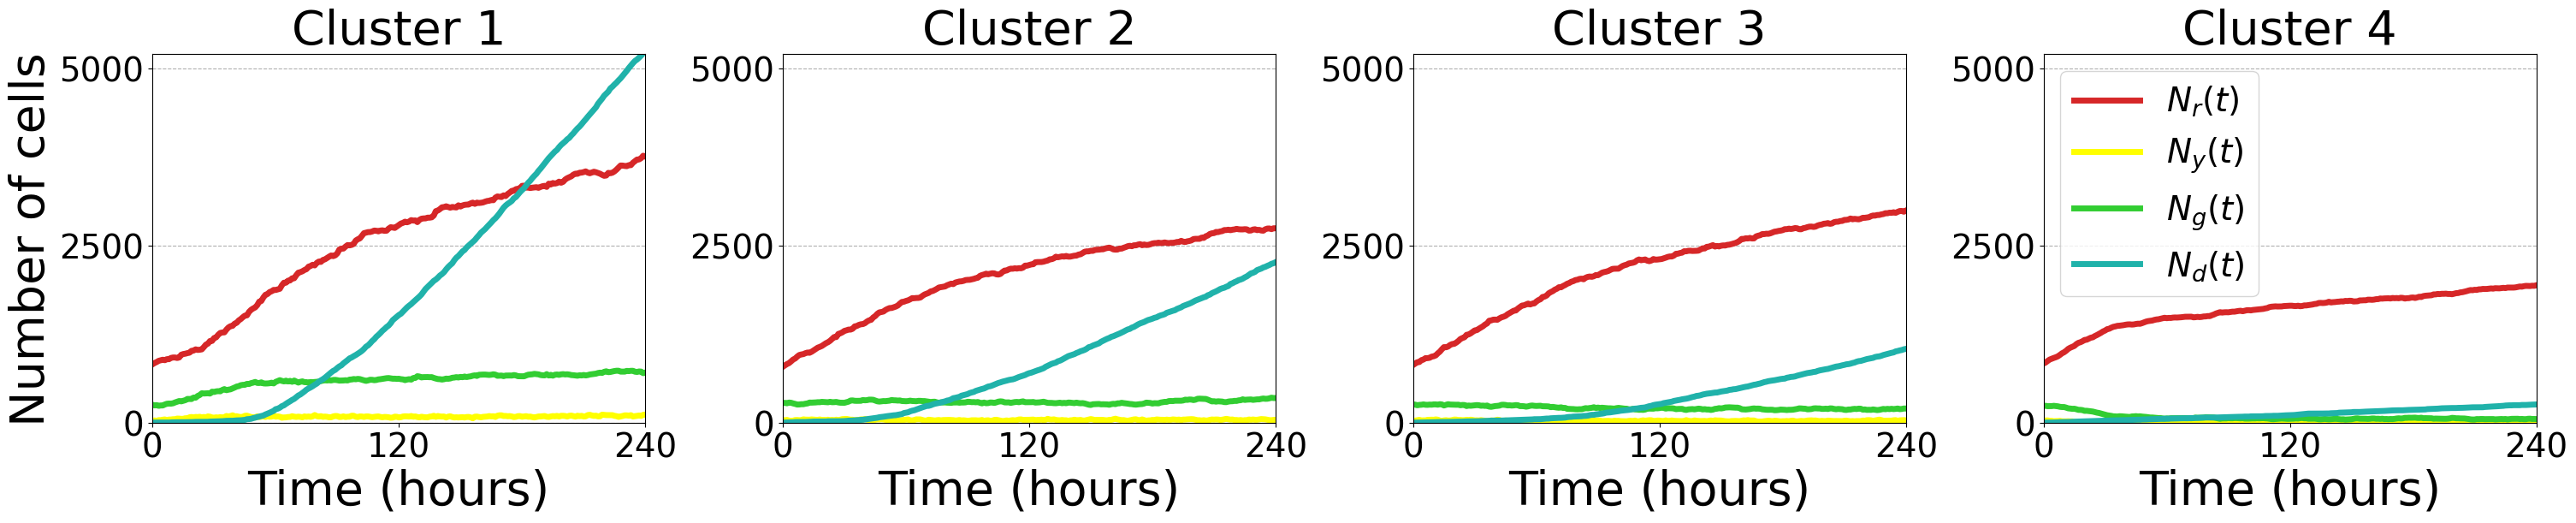

In [5]:
assert os.path.isfile("../results/dataset2/density_phenotype_inds.npy")
assert os.path.isfile("../results/dataset2/cell_counts_phenotype_inds.npy")


cell_counts_phenotype_inds = np.load("../results/dataset2/cell_counts_phenotype_inds.npy", allow_pickle = True)

fig, axes = plt.subplots(1,4, figsize = (30,6),layout="constrained")

for c, ind in enumerate(cell_counts_phenotype_inds):
    
    file_name = parse_dataset2_file_name(ind)
    out = np.load(file_name)
    plot_cell_counts(axes[c], out)

fontsize=40
for c in range(4):
    ax = axes[c]
    
    if c == 0:
        ax.set_ylabel('Number of cells', fontsize=fontsize)
    if c == 3:
        ax.legend(loc='best', fontsize = fontsize*.7)
        
    ax.set_xlabel('Time (hours)', fontsize=fontsize)
    ax.set_title(f'Cluster {c+1}', fontsize=fontsize)
    ax.set_ylim(0,5200)

    ax.set_xticks([0,120,240],[0,120,240],fontsize=28)
    ax.set_yticks([0,2500,5000],[0,2500,5000],fontsize=28)

    ax.grid(axis="y",linestyle="--")
plt.savefig('../figures/dataset2/cell_count_DVs.png')    

### Cell density

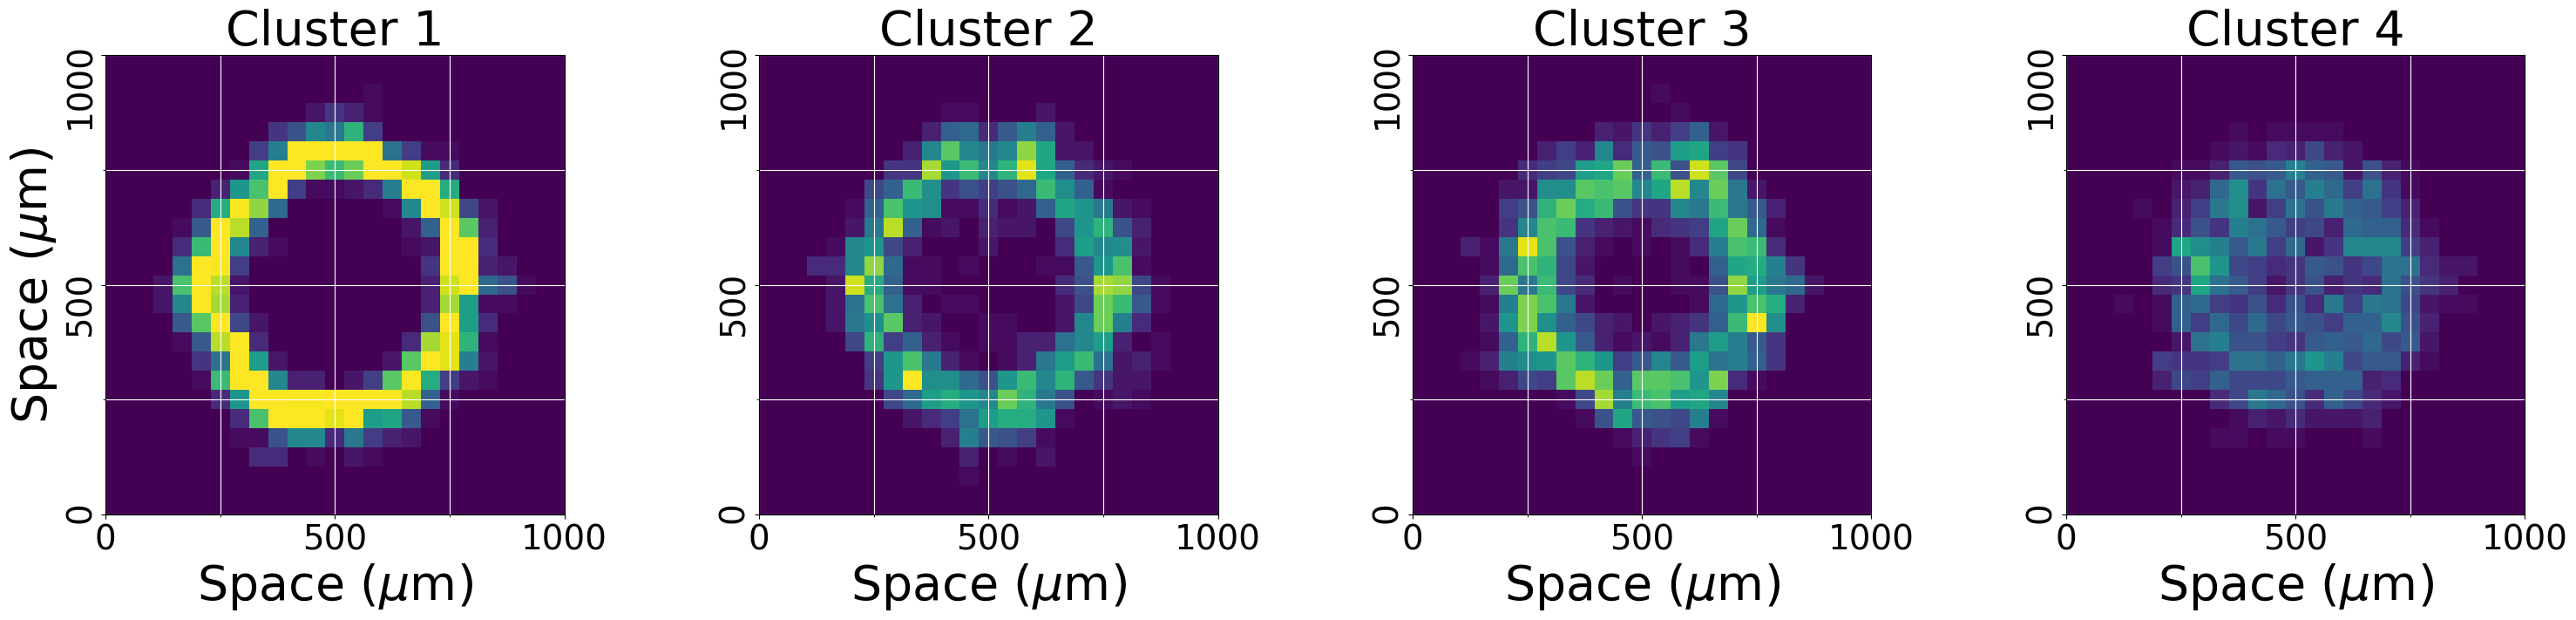

In [6]:
density_phenotype_inds = np.load("../results/dataset2/density_phenotype_inds.npy", allow_pickle = True)
coarseness = 8
coarse_resolution = (200//coarseness)

fig, axes = plt.subplots(1,4, figsize = (30,7),layout="constrained")

for c, ind in enumerate(density_phenotype_inds):
    
    file_name = parse_dataset2_file_name(ind)
    
    out = np.load(file_name, allow_pickle = True)
    
    cbar = False
    
    plot_final_density(axes[c],out,cbar)

fontsize = 40
for c in range(4):
    
    ax = axes[c]
    
    if c == 0:
        ax.set_ylabel(r"Space ($\mu$m)",fontsize=fontsize)
    
    ax.set_xlabel(r"Space ($\mu$m)",fontsize=fontsize)
    ax.set_xticks(ticks = [0, 12, 24], labels = [0, 500, 1000],fontsize=28)
    ax.set_xticks(ticks = [6,18], labels = None,minor=True)
    ax.set_yticks(ticks = [0, 12, 24], labels = [0, 500, 1000],rotation=90,fontsize=28)
    ax.set_yticks(ticks = [6,18], labels = None,minor=True)
    ax.invert_yaxis()
    
    ax.set_xlim([0,24])
    ax.set_ylim([0,24])
    
    ax.set_title(f'Cluster {c+1}', fontsize=fontsize)
    
    ax.grid(color="white",which="both")
    
plt.savefig('../figures/dataset2/final_density_DVs.png')        

In [7]:
%load_ext watermark

%watermark -n -u -v -iv -w

Last updated: Fri May 23 2025

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.25.0

yaml      : 6.0.1
src       : 0.0.0
numpy     : 1.26.4
matplotlib: 3.8.4

Watermark: 2.5.0

